Classes: ['HIGH' 'LOW' 'MEDIUM' 'NONE' 'VERY_HIGH']
CV Score v65: 0.81033
Ficheiro submission_v65_OVR_SPECIALIST.csv criado.
Imagem 'matriz_final.png' guardada.


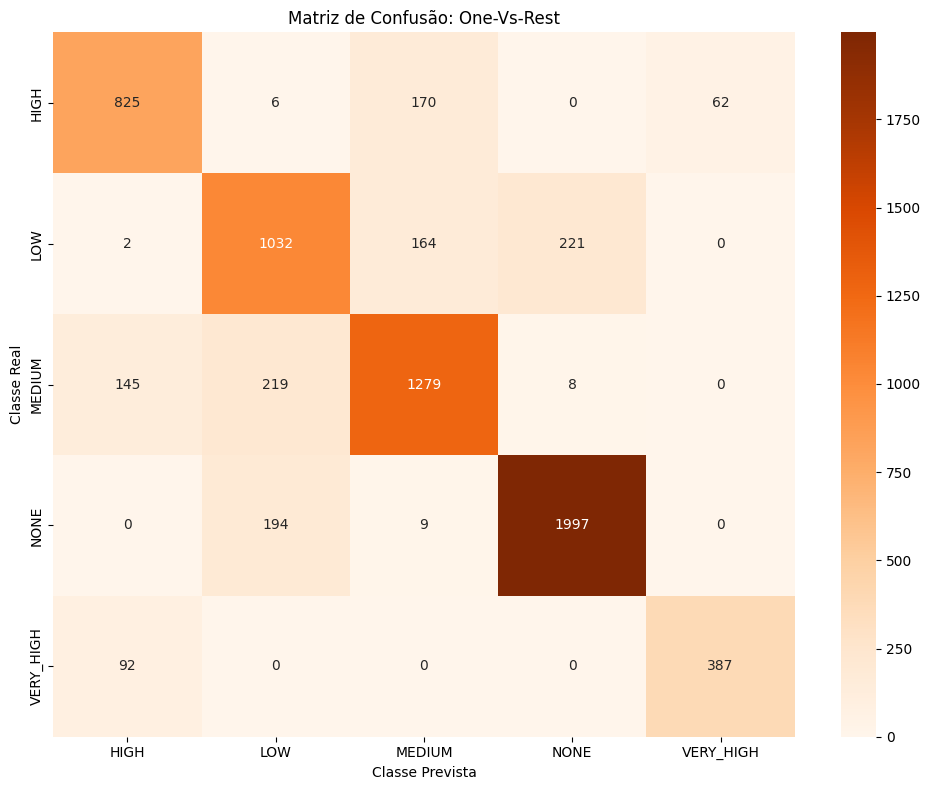


--- Métricas de Classificação (Validação Cruzada) ---
              precision  recall  f1-score  support
HIGH          0.775      0.776   0.776     1063   
LOW           0.711      0.727   0.719     1419   
MEDIUM        0.789      0.775   0.782     1651   
NONE          0.897      0.908   0.902     2200   
VERY_HIGH     0.862      0.808   0.834      479   
accuracy      0.810      0.810   0.810        0   
macro avg     0.807      0.799   0.803     6812   
weighted avg  0.811      0.810   0.810     6812   

[INFO] Tabela metricas exportada para CSV.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
import warnings

warnings.filterwarnings('ignore')

# --- 1. PRÉ-PROCESSAMENTO ---
def formatar_celula(s):
    return s.astype(str).replace('NULL', pd.NA).str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.upper().str.replace(r'[^A-Z0-9]+', '_', regex=True).str.strip('_').replace('', pd.NA)

def preprocessar_dados(df, colunas_scaler_treinadas=None, scaler=None):
    if 'RowId' in df.columns: df_final_row_ids = np.arange(1, len(df) + 1)
    else: df_final_row_ids = None
    for c in ['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN']:
        if c in df.columns: df[c] = formatar_celula(df[c]).replace('NAN', 'NONE').fillna('NONE')
    cols_drop = ['city_name', 'AVERAGE_RAIN', 'AVERAGE_PRECIPITATION', 'record_date']
    try:
        df['dt'] = pd.to_datetime(df['record_date'], format='mixed', dayfirst=True)
        df['Hora_sin'] = np.sin(2 * np.pi * df['dt'].dt.hour/24)
        df['Hora_cos'] = np.cos(2 * np.pi * df['dt'].dt.hour/24)
        df['Mes_sin'] = np.sin(2 * np.pi * df['dt'].dt.month/12)
        df['Mes_cos'] = np.cos(2 * np.pi * df['dt'].dt.month/12)
        df['DIA_SEMANA'] = df['dt'].dt.dayofweek
        df['IS_WEEKEND'] = df['dt'].dt.dayofweek.isin([5, 6]).astype(int)
        df['IS_RUSH'] = df['dt'].dt.hour.isin([7, 8, 9, 17, 18, 19]).astype(int)
        df = df.drop(columns=['dt'])
    except: pass
    df = df.drop(columns=[c for c in cols_drop if c in df.columns])
    if 'AVERAGE_CLOUDINESS' in df.columns: df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].replace('NAN', 'NONE').fillna('NONE')
    for c in ['LUMINOSITY', 'AVERAGE_CLOUDINESS', 'DIA_SEMANA']:
        if c in df.columns:
            dummies = pd.get_dummies(df[c], prefix=str(c)[:3], dtype=int)
            df = pd.concat([df, dummies], axis=1)
            df = df.drop(columns=[c])
    cols_norm = ['AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF', 'AVERAGE_FREE_FLOW_TIME','AVERAGE_TEMPERATURE', 'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY','AVERAGE_WIND_SPEED', 'IS_WEEKEND', 'IS_RUSH','Hora_sin', 'Hora_cos', 'Mes_sin', 'Mes_cos']
    cols_norm = [c for c in cols_norm if c in df.columns]
    if scaler is None:
        scaler = MinMaxScaler()
        df[cols_norm] = scaler.fit_transform(df[cols_norm])
        return df, scaler, cols_norm, df_final_row_ids
    else:
        cols_teste = [c for c in colunas_scaler_treinadas if c in df.columns]
        if cols_teste: df[cols_teste] = scaler.transform(df[cols_teste])
        return df, None, None, df_final_row_ids

# --- 2. CARREGAR E PREPARAR ---
df_train = pd.read_csv("training_data.csv", delimiter=",", encoding="latin-1")
df_test = pd.read_csv("test_data.csv", delimiter=",", encoding="latin-1")
y_raw = df_train.pop('AVERAGE_SPEED_DIFF')
test_ids = np.arange(1, len(df_test) + 1)

le = LabelEncoder()
y = le.fit_transform(formatar_celula(y_raw).replace('NAN', 'NONE').fillna('NONE'))
print(f"Classes: {le.classes_}")

X_train, scaler, cols_fit, _ = preprocessar_dados(df_train)
X_test, _, _, _ = preprocessar_dados(df_test, colunas_scaler_treinadas=cols_fit, scaler=scaler)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_train = X_train.reindex(columns=X_test.columns, fill_value=0)
X_train = X_train.fillna(0); X_test = X_test.fillna(0)

# --- 3. MODELO One-Vs-Rest ---
base_stack = StackingClassifier(
    estimators=[
        ('xgb', XGBClassifier(learning_rate=0.08, max_depth=5, n_estimators=100, random_state=42, n_jobs=1)), 
        ('lgbm', LGBMClassifier(subsample=0.9, num_leaves=50, n_estimators=200, learning_rate=0.01, random_state=42, n_jobs=1, verbose=-1))
    ],
    final_estimator=LogisticRegression(random_state=42, n_jobs=1),
    cv=5,
    n_jobs=1
)
ovr_model = OneVsRestClassifier(base_stack, n_jobs=-1)

scores = cross_val_score(ovr_model, X_train, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f"CV Score v65: {np.mean(scores):.5f}")

# Treinar
ovr_model.fit(X_train, y)
preds = ovr_model.predict(X_test)
sub = pd.DataFrame({'RowId': test_ids, 'Speed_Diff': pd.Series(le.inverse_transform(preds)).str.title()})
sub.to_csv('submission_v65_OVR_SPECIALIST.csv', index=False)
print("Ficheiro submission_v65_OVR_SPECIALIST.csv criado.")

y_pred_cv = cross_val_predict(ovr_model, X_train, y, cv=5, n_jobs=-1)
cm = confusion_matrix(y, y_pred_cv)
classes = le.inverse_transform(sorted(list(set(y))))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão: One-Vs-Rest')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.tight_layout()
plt.savefig('matriz_final.png', dpi=300)
print("Imagem 'matriz_final.png' guardada.")
plt.show()


# Relatório de Métricas 
print("\n--- Métricas de Classificação (Validação Cruzada) ---")
report_dict = classification_report(
    y, 
    y_pred_cv, 
    target_names=le.classes_, 
    output_dict=True
)
df_report = pd.DataFrame(report_dict).transpose()

# Formatação: Arredondar e limpar
df_report = df_report.round(3)
df_report['support'] = df_report['support'].astype(int)

# Imprimir alinhado à esquerda
print(df_report.to_string(justify='left'))

# 5. Exportar CSVs
df_report.to_csv('relatorio_metricas_OVR_Specialist.csv')
print("\n[INFO] Tabela metricas exportada para CSV.")